In [1]:
import uproot
import numpy as np
import pandas as pd

def dist(file, PID = False, bins = 50, use_abs = False, name = False):
    file = uproot.open(file)
    tree = file["Delphes"]

    pid = tree["Particle/Particle.PID"].array(library = "np")
    pt = tree["Particle/Particle.PT"].array(library = "np")
    eta = tree["Particle/Particle.Eta"].array(library = "np")
    phi = tree["Particle/Particle.Phi"].array(library = "np")
    charge = tree["Particle/Particle.Charge"].array(library = "np")

    events = len(pt)

    if use_abs == True:
        ind = [[i, l] for i in range(events) for l in np.where(abs(pid[i]) == PID)[0]]
        pt_p = [pt[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        eta_p = [eta[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        phi_p = [phi[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        charge_p = [charge[ind[i][0]][ind[i][1]] for i in range(len(ind))]
    else:
        ind = [[i, l] for i in range(events) for l in np.where(pid[i] == PID)[0]]
        pt_p = [pt[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        eta_p = [eta[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        phi_p = [phi[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        charge_p = [charge[ind[i][0]][ind[i][1]] for i in range(len(ind))]

    if name:
        data = {
            "P_t" + " "*1 + name: pt_p,
            "Eta" + " "*1 + name: eta_p,
            "Phi" + " "*1 + name: phi_p,
            "Charge" + " "*1 + name: charge_p
        }
    else:
        data = {
            "P_t": pt_p,
            "Eta": eta_p,
            "Phi": phi_p,
            "Charge": charge_p
        }
    data = pd.DataFrame(data)   
    data.hist(bins = bins) 
    return data

,P_t Electrons & Anti electrons,Eta Electrons & Anti electrons,Phi Electrons & Anti electrons,Charge Electrons & Anti electrons
0,17.793680,-1.372913,1.904612,0
1,3.176142,-1.671571,1.931562,0
2,17.793680,-1.372913,1.904612,0
3,3.176142,-1.671571,1.931562,0
4,1.539447,0.380803,-0.352144,0
...,...,...,...,...
450884,10.522478,-0.002050,-0.957507,0
450885,0.216487,0.391407,0.046821,0
450886,1.179893,-0.696810,-0.785486,0
450887,10.522478,-0.002050,-0.957507,0


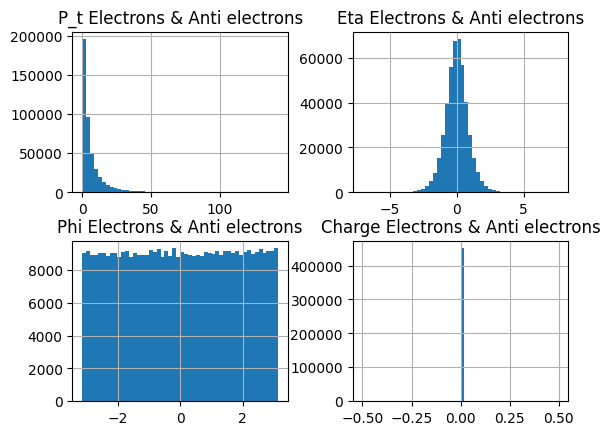

In [2]:
file = "/tf/Higgs-Boson-LHC-Collision-Detector/sigfcc_350.root"

dist(file, PID = 1, use_abs = True, bins = 50, name = "Electrons & Anti electrons")